In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 2.8 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("Libraries imported successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Libraries imported successfully!


In [ ]:
# Load pre-trained YOLOv8 model
model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully!")

YOLOv8 model loaded successfully!


In [ ]:
!wget -q -O input.jpg https://ultralytics.com/images/bus.jpg

print("Image downloaded successfully!")

Image downloaded successfully!


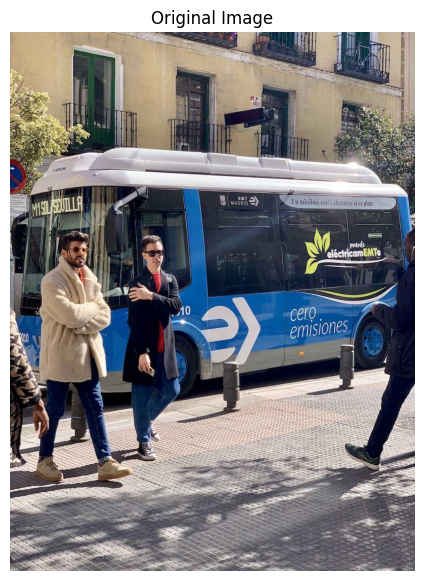

In [ ]:
image = cv2.imread("input.jpg")

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [ ]:
# Run YOLO object detection
results = model("input.jpg")

print("Object detection completed!")


image 1/1 /content/input.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 468.8ms
Speed: 34.2ms preprocess, 468.8ms inference, 43.6ms postprocess per image at shape (1, 3, 640, 480)
Object detection completed!


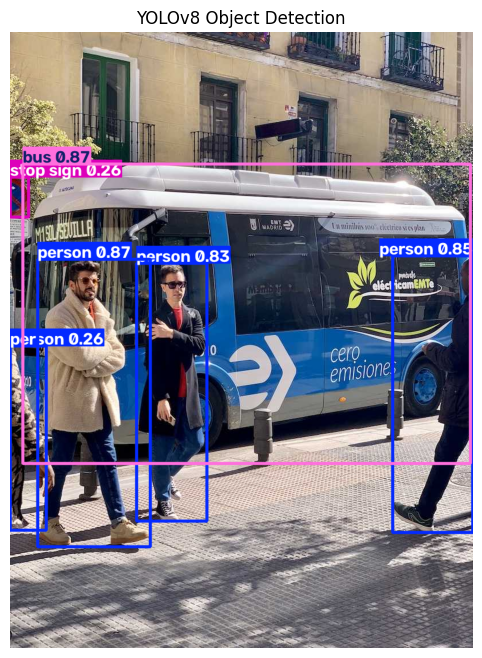

In [ ]:
# Get the annotated image
annotated_image = results[0].plot()

# Convert BGR to RGB
annotated_image_rgb = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image_rgb)
plt.axis("off")
plt.title("YOLOv8 Object Detection")
plt.show()

In [ ]:
# Extract detected object information
result = results[0]

boxes = result.boxes

print("Detected Objects:")
print("-" * 40)

for i, box in enumerate(boxes):
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    class_name = model.names[class_id]

    print(
        f"{i + 1}. {class_name} "
        f"- Confidence: {confidence:.2f}"
    )

Detected Objects:
----------------------------------------
1. bus - Confidence: 0.87
2. person - Confidence: 0.87
3. person - Confidence: 0.85
4. person - Confidence: 0.83
5. person - Confidence: 0.26
6. stop sign - Confidence: 0.26


In [ ]:
print("Bounding Box Coordinates:")
print("-" * 50)

for i, box in enumerate(boxes):
    coordinates = box.xyxy[0].cpu().numpy()
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    x1, y1, x2, y2 = coordinates

    print(f"Object {i + 1}: {model.names[class_id]}")
    print(f"Confidence: {confidence:.2f}")
    print(
        f"Bounding Box: "
        f"({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})"
    )
    print()


Bounding Box Coordinates:
--------------------------------------------------
Object 1: bus
Confidence: 0.87
Bounding Box: (22.9, 231.3, 805.0, 756.8)

Object 2: person
Confidence: 0.87
Bounding Box: (48.6, 398.6, 245.3, 902.7)

Object 3: person
Confidence: 0.85
Bounding Box: (669.5, 392.2, 809.7, 877.0)

Object 4: person
Confidence: 0.83
Bounding Box: (221.5, 405.8, 345.0, 857.5)

Object 5: person
Confidence: 0.26
Bounding Box: (0.0, 550.5, 63.0, 873.4)

Object 6: stop sign
Confidence: 0.26
Bounding Box: (0.1, 254.5, 32.6, 324.9)



In [ ]:
from collections import Counter

detected_classes = []

for box in boxes:
    class_id = int(box.cls[0])
    detected_classes.append(model.names[class_id])

object_counts = Counter(detected_classes)

print("Object Count:")
print("-" * 30)

for object_name, count in object_counts.items():
    print(f"{object_name}: {count}")

Object Count:
------------------------------
bus: 1
person: 4
stop sign: 1


In [ ]:
confidence_threshold = 0.5

filtered_objects = []

for box in boxes:
    confidence = float(box.conf[0])

    if confidence >= confidence_threshold:
        class_id = int(box.cls[0])
        filtered_objects.append(
            (model.names[class_id], confidence)
        )

print("Objects with confidence >= 0.5:")
print("-" * 40)

for name, confidence in filtered_objects:
    print(f"{name}: {confidence:.2f}")

Objects with confidence >= 0.5:
----------------------------------------
bus: 0.87
person: 0.87
person: 0.85
person: 0.83


In [ ]:
output_image = results[0].plot()

cv2.imwrite("detected_objects.jpg", output_image)

print("Detected image saved as detected_objects.jpg")

Detected image saved as detected_objects.jpg


In [ ]:
from google.colab import files

files.download("detected_objects.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_width = max(0, x2 - x1)
    intersection_height = max(0, y2 - y1)

    intersection_area = (
        intersection_width * intersection_height
    )

    area1 = (
        (box1[2] - box1[0]) *
        (box1[3] - box1[1])
    )

    area2 = (
        (box2[2] - box2[0]) *
        (box2[3] - box2[1])
    )

    union_area = area1 + area2 - intersection_area

    if union_area == 0:
        return 0

    return intersection_area / union_area


box1 = [50, 50, 200, 200]
box2 = [100, 100, 250, 250]

iou = calculate_iou(box1, box2)

print(f"IoU = {iou:.4f}")

IoU = 0.2857


In [ ]:
print("""
OBSERVATION:

1. YOLOv8 successfully detected multiple objects in the input image.
2. Each detected object was assigned a class label.
3. Bounding boxes were generated around the detected objects.
4. Confidence scores indicate the model's confidence in each detection.
5. YOLOv8 provides object detection in a single inference process,
   making it suitable for real-time computer vision applications.
""")


OBSERVATION:

1. YOLOv8 successfully detected multiple objects in the input image.
2. Each detected object was assigned a class label.
3. Bounding boxes were generated around the detected objects.
4. Confidence scores indicate the model's confidence in each detection.
5. YOLOv8 provides object detection in a single inference process,
   making it suitable for real-time computer vision applications.

